In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load dataset
df = pd.read_csv("house_data.csv")

# Show first 5 rows
print(df.head())

# Show dataset info
print(df.info())


   Id  LotArea  OverallQual  YearBuilt  TotalBsmtSF  GrLivArea  FullBath  \
0   1     8450            7       2003          856       1710         2   
1   2     9600            6       1976         1262       1262         2   
2   3    11250            7       2001          920       1786         2   
3   4     9550            7       1915          756       1717         1   
4   5    14260            8       2000         1145       2198         2   

   BedroomAbvGr  GarageCars  SalePrice  
0             3           2     208500  
1             3           2     181500  
2             3           2     223500  
3             3           3     140000  
4             4           3     250000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            20 non-null     int64
 1   LotArea       20 non-null     int64
 2   OverallQual   20 non-null

             Id       LotArea  OverallQual    YearBuilt  TotalBsmtSF  \
count  20.00000     20.000000    20.000000    20.000000     20.00000   
mean   10.50000  10415.100000     6.700000  1975.400000   1017.30000   
std     5.91608   2404.765398     0.978721    29.365931    278.18152   
min     1.00000   6120.000000     5.000000  1915.000000    700.00000   
25%     5.75000   9275.000000     6.000000  1961.500000    796.00000   
50%    10.50000  10721.500000     7.000000  1974.500000    936.00000   
75%    15.25000  11418.500000     7.000000  2003.250000   1145.00000   
max    20.00000  14260.000000     8.000000  2006.000000   1686.00000   

         GrLivArea  FullBath  BedroomAbvGr  GarageCars      SalePrice  
count    20.000000  20.00000     20.000000   20.000000      20.000000  
mean   1699.400000   1.65000      3.000000    2.200000  200170.000000  
std     334.731377   0.48936      0.561951    0.615587   61285.433145  
min    1077.000000   1.00000      2.000000    1.000000  118000.

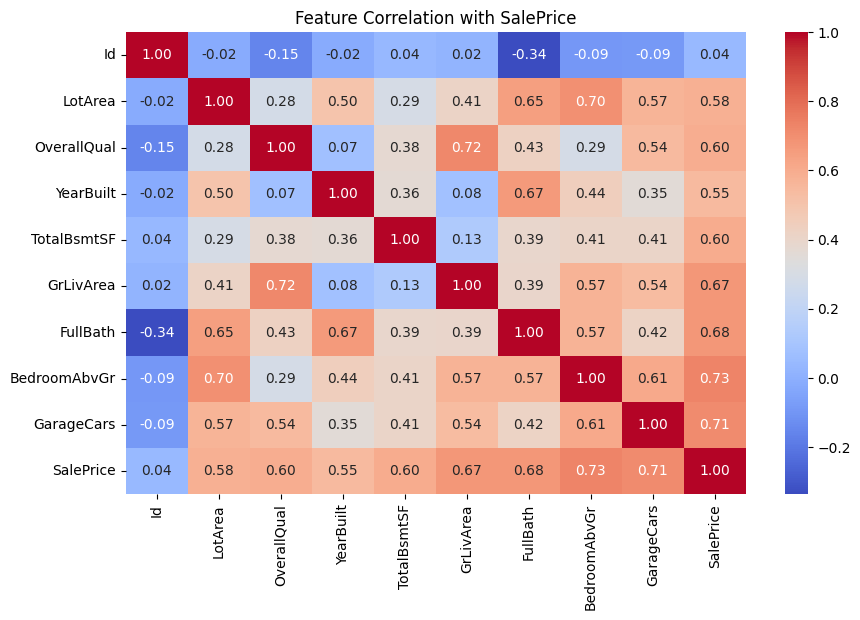

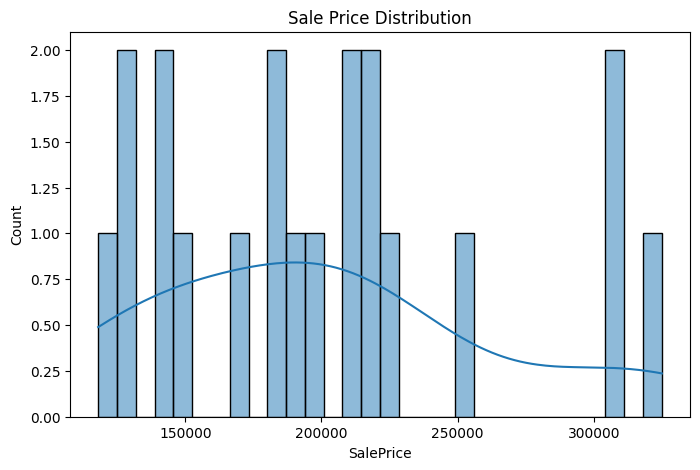

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
# Basic statistics
print(df.describe())

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation with SalePrice")
plt.show()

# Distribution of SalePrice
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], kde=True, bins=30)
plt.title("Sale Price Distribution")
plt.show()


In [30]:
print(df.isnull().sum())



Id              0
LotArea         0
OverallQual     0
YearBuilt       0
TotalBsmtSF     0
GrLivArea       0
FullBath        0
BedroomAbvGr    0
GarageCars      0
SalePrice       0
dtype: int64


In [31]:
import numpy as np
df['SalePrice'] = np.log1p(df['SalePrice'])
plt.Figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

In [32]:
df = pd.get_dummies(df, drop_first=True)  # convert categorical → numeric
X = df.drop("SalePrice", axis=1)          # features
y = df["SalePrice"]                       # target (label)


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ------------------ Linear Regression ------------------
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

lin_pred = lin_model.predict(X_test)

lin_mse = mean_squared_error(y_test, lin_pred)
lin_rmse = np.sqrt(lin_mse)
lin_r2 = r2_score(y_test, lin_pred)

print("----- Linear Regression -----")
print("RMSE:", lin_rmse)
print("R² Score:", lin_r2)


# ------------------ Random Forest Regressor ------------------
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("\n----- Random Forest Regressor -----")
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)


----- Linear Regression -----
RMSE: 0.15308673293628997
R² Score: 0.37305622825265683

----- Random Forest Regressor -----
RMSE: 0.12352262349311899
R² Score: 0.5918249102494766


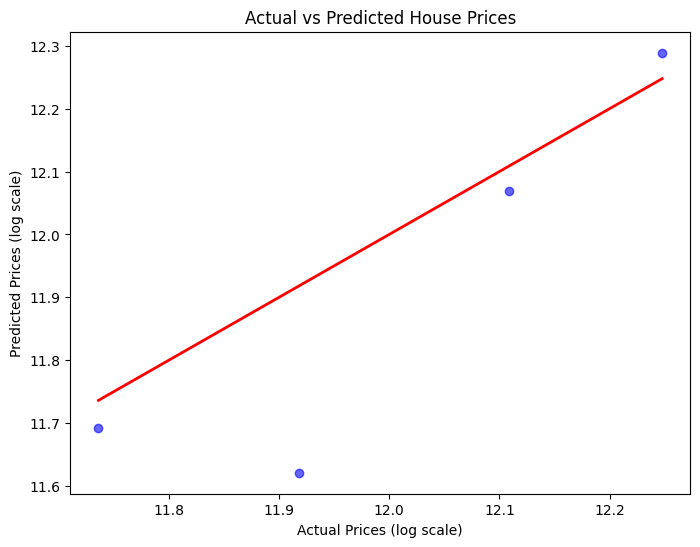

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color="blue")
plt.xlabel("Actual Prices (log scale)")
plt.ylabel("Predicted Prices (log scale)")
plt.title("Actual vs Predicted House Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linewidth=2) # Perfect prediction line
plt.show()


In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
import numpy as np

# Define parameter distribution for tuning
param_dist = {
    'n_estimators': randint(100, 500),       # number of trees
    'max_depth': [None, 10, 20, 30, 40],     # tree depth
    'min_samples_split': randint(2, 10),     # min samples to split
    'min_samples_leaf': randint(1, 5),       # min samples in leaf
    'max_features': ['auto', 'sqrt']         # features considered at each split
}

# Create RandomForest model
rf = RandomForestRegressor(random_state=42)

# RandomizedSearchCV for faster hyperparameter tuning
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,             # number of random combinations to try
    cv=3,                  # 3-fold cross-validation
    n_jobs=-1,             # use all CPU cores
    scoring='neg_mean_squared_error',
    verbose=2,
    random_state=42
)

# Fit the model
random_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", random_search.best_params_)

# Predict with the best model
best_rf = random_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

# Evaluate
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Tuned Random Forest RMSE:", rmse_rf)
print("Tuned Random Forest R²:", r2_rf)


Fitting 3 folds for each of 20 candidates, totalling 60 fits


c:\Users\Admin\OneDrive\Desktop\House_price_prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
27 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
9 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Admin\OneDrive\Desktop\House_price_prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Admin\OneDrive\Desktop\House_price_prediction\.venv\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~

Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 443}
Tuned Random Forest RMSE: 0.11981461541797477
Tuned Random Forest R²: 0.6159629906746948
